                                                    Лабораторна робота №3“Кластеризація”
                                                     Виконала Доля Анастасія КН-42-03
Мета: Ознайомитися з методами кластеризації (clustering) на прикладі реального набору музичних даних Spotify Tracks Dataset. Навчитись підбирати оптимальну кількість кластерів (k) за допомогою методу ліктя (elbow), виконувати кластеризацію методом K-Means, знижувати розмірність простору ознак за допомогою PCA для візуалізації та аналізувати характеристики утворених кластерів.

In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

DATA_DIR = r'C:\Users\Anastasia\Downloads\archive\SpotifyFeatures.csv'
df = pd.read_csv(DATA_DIR)

In [49]:
print("Перші 5 рядків:")
display(df.head())

print("\nРозмір таблиці:")
print(df.shape)

print("\nІнформація про DataFrame:")
print(df.info())

print("\nКількість пропусків:")
print(df.isnull().sum())

print("\nОпис числових колонок:")
display(df.describe())

Перші 5 рядків:


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390



Розмір таблиці:
(232725, 18)

Інформація про DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  str    
 1   artist_name       232725 non-null  str    
 2   track_name        232724 non-null  str    
 3   track_id          232725 non-null  str    
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  str    
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  str    
 14  speechiness       232725 non-null  float64
 15  tempo             2327

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


Було завантажено датасет Spotify Tracks Dataset, який містить 232725 записів і 18 ознак. Дані включають текстові характеристики та числові аудіо-ознаки.Пропуски практично відсутні (лише 1 пропуск у колонці track_name), що не впливає на подальший аналіз.

In [50]:
#1с
audio_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

# Перевірка, чи всі потрібні колонки є
missing_cols = [col for col in audio_features if col not in df.columns]
if missing_cols:
    raise ValueError(f"У датасеті відсутні колонки: {missing_cols}")

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[audio_features])

print("\nРозмірність матриці ознак після стандартизації:")
print(X_scaled.shape)


Розмірність матриці ознак після стандартизації:
(232725, 9)


Для кластеризації було обрано лише аудіо-ознаки: danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence та tempo.
Ознака popularity не використовувалась для кластеризації, оскільки вона не є аудіо-характеристикою, а відображає популярність треку.
Було виконано стандартизацію ознак за допомогою StandardScaler. У результаті всі ознаки були приведені до однакового масштабу (середнє 0, стандартне відхилення 1).

In [ ]:
# 6. Фільтрація популярних треків для візуалізації
popular_mask = df['popularity'] >= 85
df_popular_original = df[popular_mask].copy()

print("\nРозмірність таблиці після фільтрації popularity >= 85:")
print(df_popular_original.shape)


Розмірність таблиці після фільтрації popularity >= 85:
(417, 18)


Для подальшої візуалізації було відібрано треки з популярністю popularity ≥ 85.У результаті було отримано 417 треків, які використовуються для візуалізації кластерів.

In [53]:
#2a
inertia = []

k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)


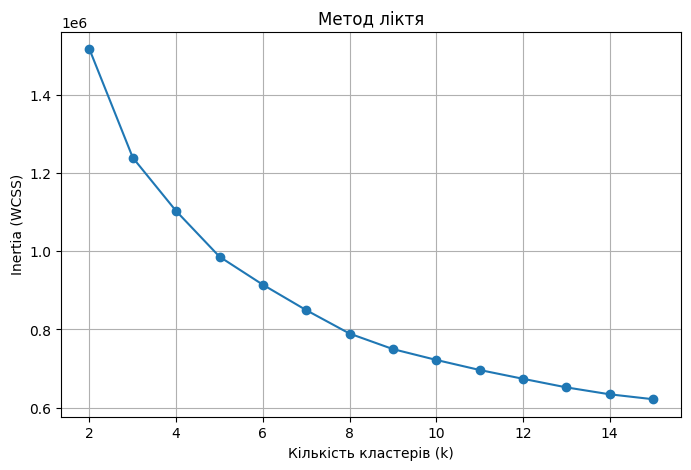

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertia, marker='o')
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Метод ліктя')
plt.grid(True)
plt.show()


Для визначення оптимальної кількості кластерів було використано метод ліктя. Для значень k від 2 до 15 обчислено значення inertia (сума квадратів відстаней до центрів кластерів).
З графіка видно, що найбільш різке зменшення inertia відбувається до приблизно k = 5, після чого зменшення стає більш плавним. Це свідчить про те, що додавання нових кластерів після цього значення дає незначне покращення.
Тому оптимальне значення було обрано як k = 5.

In [55]:
#3a
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("\nКількість треків у кожному кластері:")
print(df['cluster'].value_counts().sort_index())


Кількість треків у кожному кластері:
cluster
0    45056
1    65206
2    84785
3    10142
4    27536
Name: count, dtype: int64


Розподіл об’єктів по кластерах є нерівномірним: найбільший кластер містить 84785 треків, а найменший — 10142. Це свідчить про те, що деякі типи треків є значно більш поширеними в датасеті.

Загалом сума об’єктів у всіх кластерах дорівнює розміру датасету.

In [56]:
#4a
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

print("\nЧастка поясненої дисперсії PCA:")
print(pca.explained_variance_ratio_)
print("Сумарно:", pca.explained_variance_ratio_.sum())



Частка поясненої дисперсії PCA:
[0.38312835 0.18022703]
Сумарно: 0.5633553837833012


Для візуалізації кластерів було застосовано метод головних компонент (PCA) із зменшенням розмірності до 2 компонент.
Перші дві компоненти пояснюють приблизно 56.3% дисперсії, що є достатнім для візуального аналізу, хоча частина інформації втрачається.

In [ ]:
df_popular = df[df['popularity'] >= 85].copy()

print("\nКількість популярних треків для візуалізації:")
print(df_popular.shape[0])

print("\nКількість популярних треків у кожному кластері:")
print(df_popular['cluster'].value_counts().sort_index())



Кількість популярних треків для візуалізації:
417

Кількість популярних треків у кожному кластері:
cluster
0     33
1    110
2    274
Name: count, dtype: int64


Серед популярних треків (417 записів) найбільше належать до кластера 2 (274 треки), значно менше - до кластерів 1 (110) та 0 (33). Кластери 3 і 4 відсутні.

Це означає, що найбільш популярні треки мають характерні ознаки саме кластера 2, тоді як треки інших типів рідше досягають високої популярності.

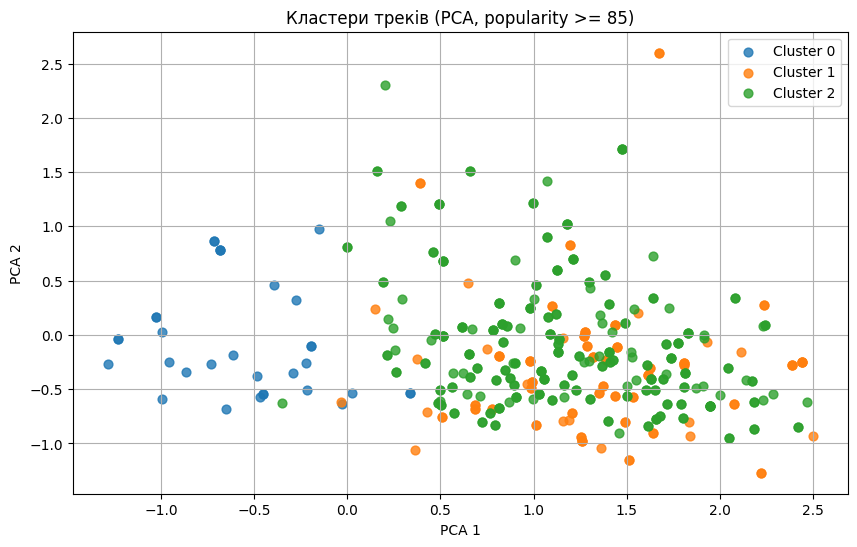

In [58]:
plt.figure(figsize=(10, 6))

for cluster in sorted(df_popular['cluster'].unique()):
    subset = df_popular[df_popular['cluster'] == cluster]
    plt.scatter(
        subset['pca1'],
        subset['pca2'],
        label=f'Cluster {cluster}',
        s=40,
        alpha=0.8
    )

plt.title('Кластери треків (PCA, popularity >= 85)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

На графіку відображено лише популярні треки (popularity ≥ 85). Видно, що найбільшу частину таких треків становить кластер 2, тоді як кластери 3 і 4 серед популярних треків відсутні.

Бачимо,що популярні треки мають певні спільні аудіо-характеристики.

In [59]:
#5.1
cluster_stats = df.groupby('cluster')[audio_features].mean()
print("\nСередні значення аудіо-ознак по кластерах:")
display(cluster_stats)


Середні значення аудіо-ознак по кластерах:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.503398,0.330317,-12.067212,0.065421,0.700776,0.065094,0.179147,0.333459,111.712266
1,0.503533,0.766553,-5.945379,0.093628,0.100463,0.091459,0.244616,0.432824,142.728339
2,0.704371,0.668754,-7.057443,0.104930,0.193868,0.059814,0.172164,0.638371,108.818007
3,0.562819,0.663492,-11.987054,0.877278,0.789213,0.001191,0.729041,0.414694,98.020536
4,0.293137,0.166330,-20.912220,0.045703,0.842787,0.745694,0.146178,0.155917,102.543763


Інтерпретація:

Кластер 0 - спокійні, акустичні треки
(високий acousticness, низька energy та loudness)

Кластер 1 - енергійні та швидкі треки
(високі energy, tempo, loudness, низька acousticness)

Кластер 2 - танцювальні та “позитивні” треки
(високі danceability, valence, достатньо висока energy)

Кластер 3 - нетипові або “розмовні” треки
(дуже висока speechiness і liveness)

Кластер 4 - інструментальні та тихі композиції
(дуже високий instrumentalness, низька energy)

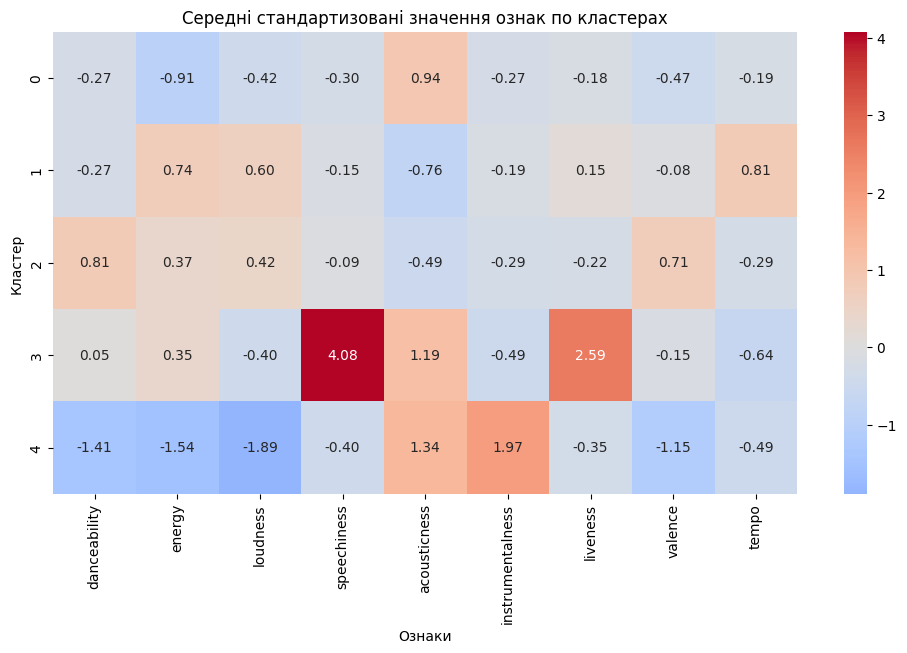

In [ ]:
df_scaled_features = pd.DataFrame(X_scaled, columns=audio_features)
df_scaled_features['cluster'] = df['cluster']

# середні стандартизовані значення по кластерах
cluster_stats_scaled = df_scaled_features.groupby('cluster')[audio_features].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_stats_scaled,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0
)
plt.title("Середні стандартизовані значення ознак по кластерах")
plt.xlabel("Ознаки")
plt.ylabel("Кластер")
plt.show()

Візуалізація розподілу за heatmap дозволяє коректно порівнювати ознаки між кластерами, оскільки всі вони приведені до одного масштабу.
Значення більше нуля означають, що відповідна ознака в кластері вища за середню по датасету, а значення менше нуля — нижча за середню.

Завдяки цьому чітко видно відмінності між кластерами:
кластер 2 має високі значення danceability і valence;
кластер 1 - високі energy і tempo;
кластер 4 - дуже низькі energy і loudness, але високий instrumentalness.

In [ ]:
# Додатково: середня popularity по кластерах
# Не використовуємо popularity для кластеризації,але можемо окремо подивитись, як вона розподілилась.
popularity_by_cluster = df.groupby('cluster')['popularity'].mean().sort_index()

print("\nСередня popularity по кластерах:")
print(popularity_by_cluster)

print("\nПриклади треків з кожного кластера:")
for cluster in sorted(df['cluster'].unique()):
    print(f"\n=== Cluster {cluster} ===")
    display(df[df['cluster'] == cluster][
        ['artist_name', 'track_name', 'genre', 'popularity']
    ].head(5))


Середня popularity по кластерах:
cluster
0    38.289062
1    44.860044
2    46.211323
3    21.308125
4    28.579605
Name: popularity, dtype: float64

Приклади треків з кожного кластера:

=== Cluster 0 ===


,artist_name,track_name,genre,popularity
2,Joseph Williams,Don't Let Me Be Lonely Tonight,Movie,3
3,Henri Salvador,Dis-moi Monsieur Gordon Cooper,Movie,0
4,Fabien Nataf,Ouverture,Movie,4
5,Henri Salvador,Le petit souper aux chandelles,Movie,0
7,Laura Mayne,Let Me Let Go,Movie,15



=== Cluster 1 ===


,artist_name,track_name,genre,popularity
0,Henri Salvador,C'est beau de faire un Show,Movie,0
1,Martin & les fées,Perdu d'avance (par Gad Elmaleh),Movie,1
19,Amalya,Ladies And Gentlemen,Movie,4
51,Chantal Goya,Animauxville (Départ) - Live,Movie,5
59,Chorus,Shree Ram Chant,Movie,4



=== Cluster 2 ===


,artist_name,track_name,genre,popularity
8,Chorus,Helka,Movie,0
9,Le Club des Juniors,Les bisous des bisounours,Movie,10
12,Idoles De La Musique,J'ai demandé à la lune,Movie,4
17,Bernard Minet,Ultra Man 80,Movie,3
21,Dorothée,Clic clac cloc,Movie,1



=== Cluster 3 ===


,artist_name,track_name,genre,popularity
6,Martin & les fées,"Premières recherches (par Paul Ventimila, Lori...",Movie,2
15,Michel Roux,Les aventures d'Arsène Lupin: 813 - Partie 6,Movie,0
31,Martin & les fées,Une journée d'école qui s'achève (par Véroniqu...,Movie,4
44,Ken Page,Dancing with Gene,Movie,0
52,Henri Salvador,Sketch producteur (suite),Movie,1



=== Cluster 4 ===


,artist_name,track_name,genre,popularity
10,Leopold Stokowski,Symphony No.4 In E Minor Op.98 : IV. Allegro E...,Movie,0
11,Randy Newman,The Hanging (Maverick - Original Motion Pictur...,Movie,2
14,Richard M. Sherman,Keys of Love,Movie,0
38,Richard M. Sherman,Afterglow,Movie,0
41,Leopold Stokowski,"Bourrée, From English Suite No. 2, BWV 807",Movie,1


Найвищу середню популярність має кластер 2 (46.21), далі кластер 1 (44.86) і кластер 0 (38.29). Найнижчі значення спостерігаються для кластерів 4 (28.58) та 3 (21.31).

Отримані результати узгоджуються з попереднім аналізом популярних треків.
серед треків із popularity ≥ 85 присутні лише кластери 0, 1 і 2, тоді як кластери 3 і 4 відсутні. Це підтверджує, що треки цих кластерів рідко досягають високої популярності.

Змістовно це пояснюється тим, що кластери 1 і 2 відповідають енергійним і танцювальним композиціям, які є більш привабливими для широкої аудиторії. Натомість кластери 3 і 4 містять розмовні або інструментальні треки, які мають більш вузьку аудиторію і, відповідно, нижчу популярність.

Висновок.У роботі було виконано кластеризацію треків Spotify за допомогою методу K-Means. Було визначено оптимальну кількість кластерів за допомогою методу ліктя.
Для візуалізації використано PCA. Аналіз показав, що треки можна розділити на кілька типів: енергійні, танцювальні, акустичні, інструментальні та нетипові.
Було встановлено, що найбільш популярні треки належать переважно до одного кластеру, що свідчить про наявність характерних аудіо-ознак популярної музики.